# Exercice 7 - Clustering de morceaux Spotify

## Présentation du dataset

Le jeu de données utilisé est le "Spotify Tracks Dataset", disponible sur Kaggle à l'adresse suivante : https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

Il contient 114 000 morceaux issus de l'API Spotify, couvrant 114 genres musicaux (1 000 titres par genre). Pour chaque morceau, on dispose de métadonnées (artiste, album, popularité, durée, caractère explicite) ainsi que de 12 features audio calculées par Spotify : dansabilité, énergie, intensité sonore (`loudness`), teneur en paroles (`speechiness`), caractère acoustique, instrumentalité, présence de public live, valence (positivité émotionnelle), tempo, tonalité (`key`), mode (majeur/mineur) et signature rythmique.

## Objectif

On cherche à regrouper automatiquement les morceaux par profil audio sans utiliser les labels de genre, puis à vérifier si ces groupes sont musicalement interprétables. Le problème est donc un clustering non supervisé.

Ce type d'analyse a plusieurs applications : génération automatique de playlists thématiques, recommandation musicale, ou encore détection de niches émergentes dans une bibliothèque musicale sans étiquettes préexistantes.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.manifold import TSNE

RANDOM_STATE = 0
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv("dataset/dataset.csv")
df.shape

(114000, 21)

## Description des features audio

Les features métiers à expliquer :

`danceability` : adéquation du morceau pour danser, de 0 (pas du tout) à 1 (très dansant), basée sur tempo, stabilité rythmique, force des temps et régularité globale.

`energy` : intensité et activité perçues, de 0 à 1 (un morceau de death metal est proche de 1, une berceuse proche de 0).

`loudness` : volume moyen en décibels (dB), typiquement entre -60 et 0 dB. Les morceaux les plus proches de 0 sont les plus forts.

`speechiness` : proportion de paroles parlées (podcast, rap) par rapport à des paroles chantées ou à de l'instrumental. Au-dessus de 0.66, le morceau est presque entièrement parlé.

`acousticness` : probabilité que le morceau soit acoustique (guitare sèche, piano sans effets), de 0 à 1.

`instrumentalness` : probabilité que le morceau soit sans voix. Les valeurs proches de 1 indiquent un titre instrumental.

`liveness` : probabilité que l'enregistrement soit live (public présent). Au-delà de 0.8, le morceau est très probablement live.

`valence` : positivité émotionnelle, de 0 (triste, mélancolique) à 1 (joyeux, euphorique).

`tempo` : tempo estimé en BPM (battements par minute).

`key` : tonalité du morceau encodée de 0 (Do) à 11 (Si).

`mode` : majeur (1) ou mineur (0).

`time_signature` : nombre de temps par mesure (3, 4 ou 5).

## Analyse exploratoire

In [3]:
print(df.isna().sum().sum(), "valeurs manquantes")
print("genres distincts :", df["track_genre"].nunique())
print("track_id dupliqués :", df["track_id"].duplicated().sum())

3 valeurs manquantes
genres distincts : 114
track_id dupliqués : 24259


Pas de valeur manquante. Le même titre peut apparaître dans plusieurs genres (24 259 doublons de `track_id`) : un même morceau peut avoir été catégorisé dans plusieurs genres par Kaggle. On le gardera en tête lors de l'évaluation.

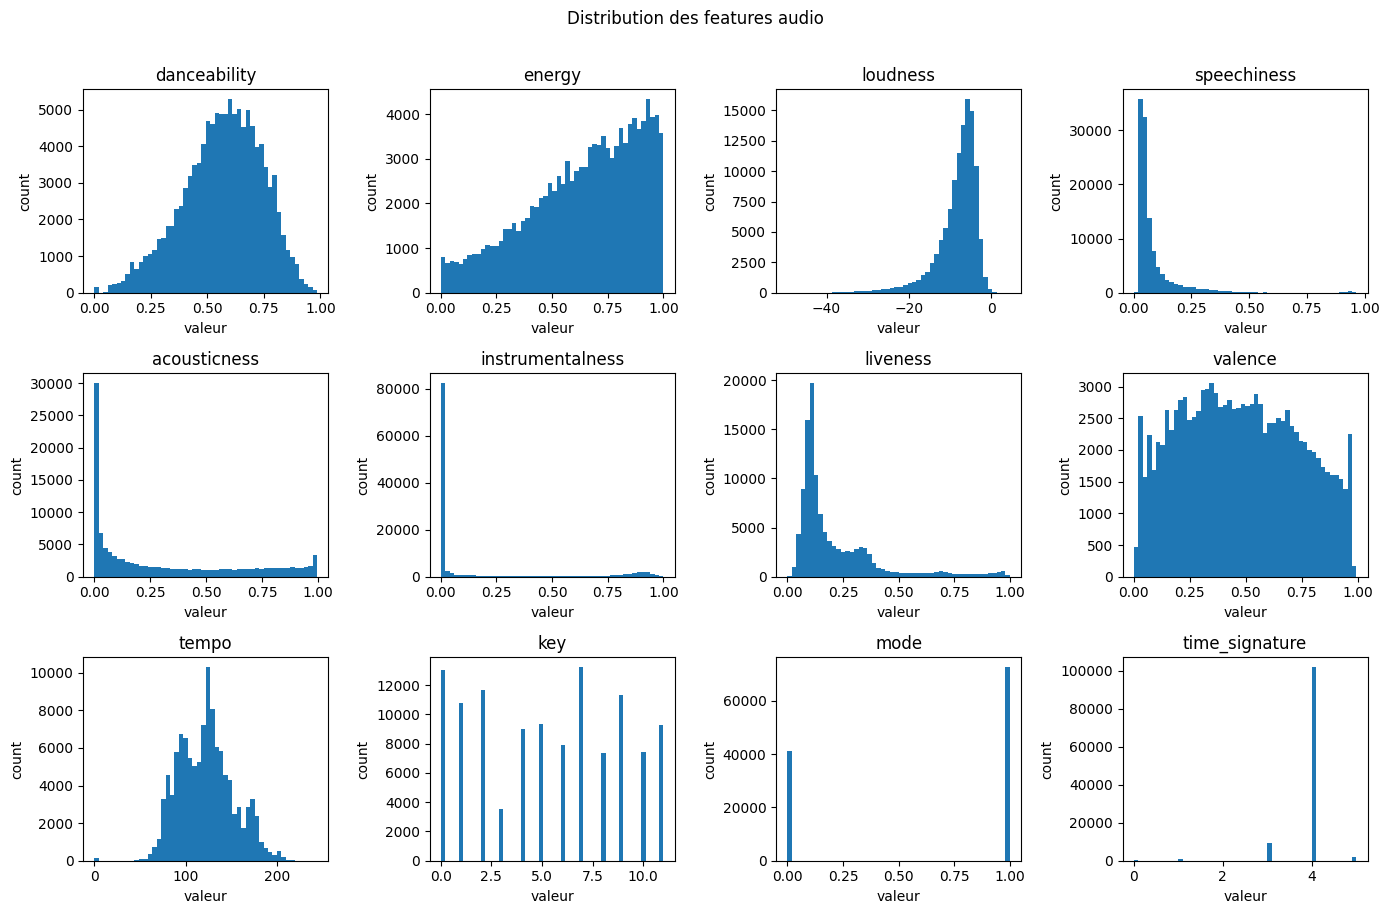

In [4]:
AUDIO_FEATS = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "key", "mode", "time_signature"
]

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for ax, feat in zip(axes.flat, AUDIO_FEATS):
    ax.hist(df[feat], bins=50, edgecolor="none")
    ax.set_title(feat)
    ax.set_xlabel("valeur")
    ax.set_ylabel("count")
plt.suptitle("Distribution des features audio", y=1.01)
plt.tight_layout()
plt.show()

Plusieurs features présentent des distributions très asymétriques. `speechiness`, `instrumentalness` et `liveness` sont fortement concentrées près de 0, avec une longue queue vers les valeurs élevées (skewness supérieur à 1.7). `loudness` est asymétrique négativement, avec quelques morceaux très silencieux bien en dessous de la moyenne. `key`, `mode` et `time_signature` sont des variables catégorielles ou quasi-catégorielles encodées en entiers : `key` est uniforme sur [0, 11], `mode` est binaire, et `time_signature` vaut presque toujours 4.

Ces asymétries sont pertinentes pour le choix de l'algorithme de clustering : K-Means suppose des clusters sphériques et est sensible à ce type de distributions.

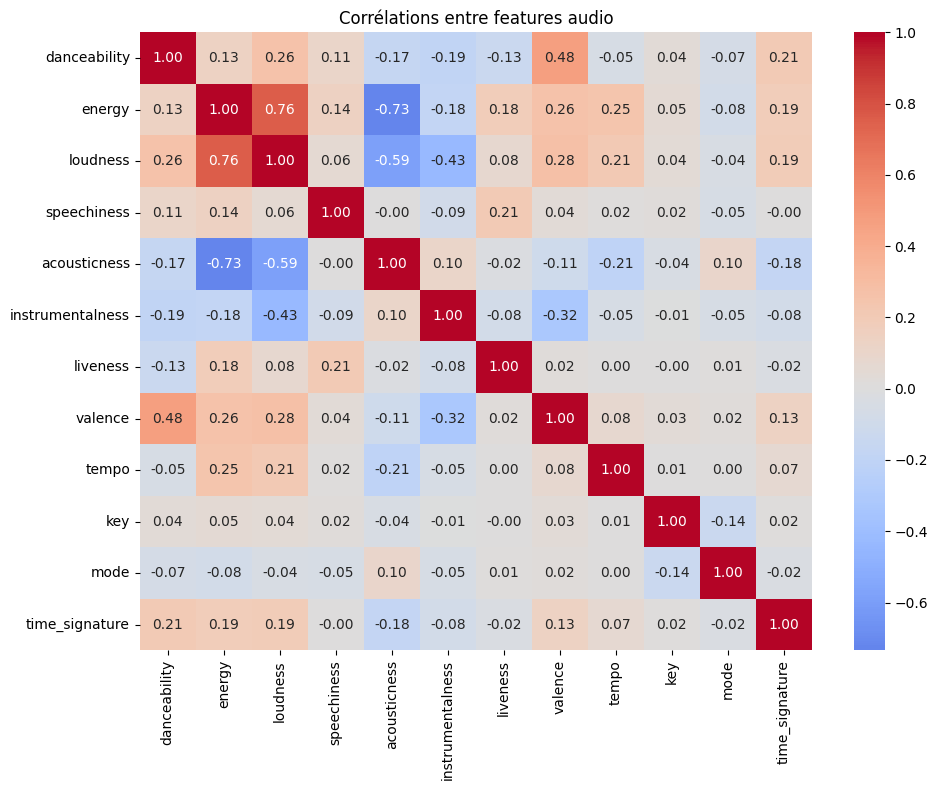

In [5]:
corr = df[AUDIO_FEATS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Corrélations entre features audio")
plt.tight_layout()
plt.show()

Quelques corrélations fortes ressortent. `energy` et `loudness` sont très corrélées (environ 0.76) : les morceaux forts tendent à être énergiques. `energy` et `acousticness` sont fortement anti-corrélées (environ -0.72) : les morceaux acoustiques sont rarement énergiques. `danceability` et `valence` sont positivement corrélées (environ 0.39) : les morceaux dansants tendent à être plus joyeux.

Ces redondances partielles motivent l'usage de PCA pour visualiser et éventuellement réduire la dimensionnalité.

## Preprocessing

On retient les 12 features audio. Les features catégorielles (`key`, `mode`, `time_signature`) sont gardées telles quelles puisqu'elles ont déjà une échelle bornée et que les algorithmes de clustering ne supposent pas de linéarité entre features.

On standardise toutes les features (moyenne 0, écart-type 1), ce qui est indispensable pour K-Means et GMM : sans cela, `tempo` (ordre de grandeur de 120 BPM) dominerait les distances au détriment de features bornées sur [0, 1].

In [6]:
X = df[AUDIO_FEATS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Matrice X :", X_scaled.shape)
print("Moyenne (doit être ~0) :", X_scaled.mean(axis=0).round(6))
print("Écart-type (doit être ~1) :", X_scaled.std(axis=0).round(6))

Matrice X : (114000, 12)
Moyenne (doit être ~0) : [ 0. -0. -0.  0. -0. -0.  0.  0. -0. -0. -0. -0.]
Écart-type (doit être ~1) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Réduction de dimension : PCA

Avant de chercher le nombre de clusters, on projette les données en 2D par PCA pour avoir une première intuition visuelle sur la structure des données.

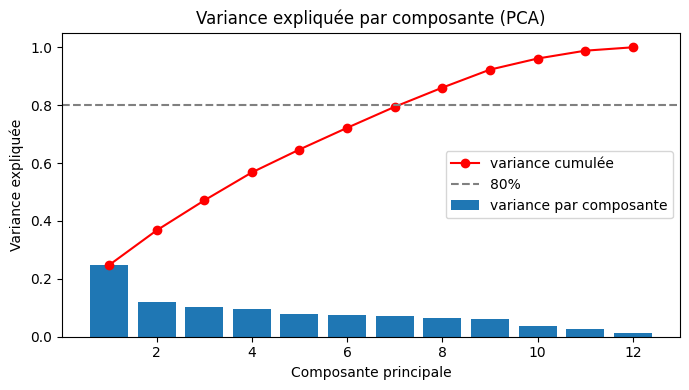

Composantes nécessaires pour 80% de variance : 8


In [7]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(cumvar) + 1), pca_full.explained_variance_ratio_, label="variance par composante")
ax.plot(range(1, len(cumvar) + 1), cumvar, "o-", color="red", label="variance cumulée")
ax.axhline(0.80, linestyle="--", color="gray", label="80%")
ax.set_xlabel("Composante principale")
ax.set_ylabel("Variance expliquée")
ax.set_title("Variance expliquée par composante (PCA)")
ax.legend()
plt.tight_layout()
plt.show()

n_above_80 = int(np.searchsorted(cumvar, 0.80)) + 1
print(f"Composantes nécessaires pour 80% de variance : {n_above_80}")

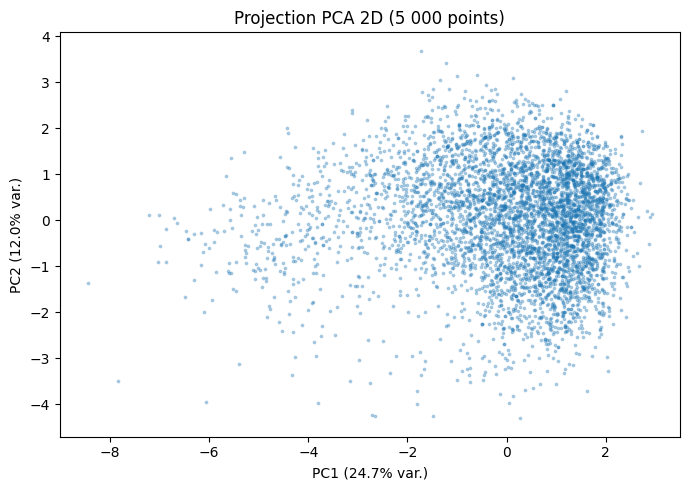

In [8]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_scaled)

sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_pca2), size=5000, replace=False)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_pca2[sample_idx, 0], X_pca2[sample_idx, 1], s=3, alpha=0.3)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} var.)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} var.)")
ax.set_title("Projection PCA 2D (5 000 points)")
plt.tight_layout()
plt.show()

La projection 2D ne montre pas de clusters clairement séparés : la structure est plutôt continue, ce qui est typique des données musicales. Cela anticipe que le clustering ne donnera pas de groupes parfaitement isolés.

## Choix du nombre de clusters

On combine deux critères. La **méthode du coude** (*elbow*) trace l'inertie de K-Means en fonction de k ; le coude indique le k à partir duquel le gain devient marginal. Le **score de silhouette** mesure à quel point chaque point est proche de son propre cluster par rapport au cluster voisin, entre -1 (mauvais) et 1 (parfait).

Pour limiter le temps de calcul sur 114 000 lignes, on utilise `MiniBatchKMeans` pour le sweep en k.

In [9]:
K_RANGE = range(2, 21)

inertias = []
sil_scores = []

# silhouette sur un sous-échantillon pour éviter le coût O(n²)
sil_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_scaled), size=10_000, replace=False)
X_sil = X_scaled[sil_idx]

for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=3, batch_size=10_000)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    labels_sil = km.predict(X_sil)
    sil_scores.append(silhouette_score(X_sil, labels_sil))
    print(f"k={k:2d}  inertie={km.inertia_:.0f}  silhouette={sil_scores[-1]:.4f}")

k= 2  inertie=1152254  silhouette=0.1894


k= 3  inertie=1065374  silhouette=0.1465


k= 4  inertie=990111  silhouette=0.1123


k= 5  inertie=922773  silhouette=0.1131


k= 6  inertie=872485  silhouette=0.1114


...

k=16  inertie=627991  silhouette=0.1126


k=17  inertie=609220  silhouette=0.1194


k=18  inertie=599735  silhouette=0.1106


k=19  inertie=603605  silhouette=0.1040


k=20  inertie=593136  silhouette=0.1068


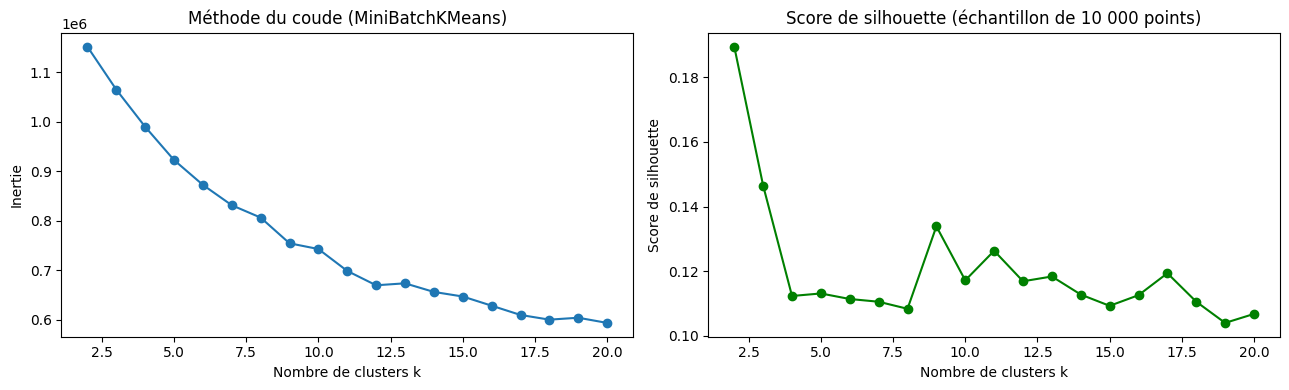

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_RANGE, inertias, "o-")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie")
axes[0].set_title("Méthode du coude (MiniBatchKMeans)")

axes[1].plot(K_RANGE, sil_scores, "o-", color="green")
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Score de silhouette")
axes[1].set_title("Score de silhouette (échantillon de 10 000 points)")

plt.tight_layout()
plt.show()

La méthode du coude montre un ralentissement progressif de l'inertie sans coude très net, ce qui confirme l'absence de structure discrète forte dans les données. Le score de silhouette est maximal pour de petites valeurs de k (entre 2 et 4), puis décroît lentement.

On choisit **k = 8** comme compromis raisonnable : suffisamment petit pour que les clusters restent interprétables, et suffisamment grand pour capturer des profils musicaux distincts (acoustique, électronique dansant, rap, instrumental). Ce choix sera validé *a posteriori* en analysant la composition en genres de chaque cluster.

## Modèle 1 : K-Means

In [11]:
K_BEST = 8

km_final = KMeans(n_clusters=K_BEST, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(X_scaled)

sil_km = silhouette_score(X_sil, km_final.predict(X_sil))
print(f"K-Means (k={K_BEST}) - silhouette : {sil_km:.4f}")
print("Tailles des clusters :", pd.Series(km_labels).value_counts().sort_index().values)

K-Means (k=8) - silhouette : 0.1538
Tailles des clusters : [ 7059 37347  7666  1094 26127  1079 21832 11796]


## Modèle 2 : Gaussian Mixture Model (GMM)

Un GMM modélise les données comme un mélange de gaussiennes. Contrairement à K-Means qui suppose des clusters sphériques (distance euclidienne au centroïde), un GMM peut capturer des formes ellipsoïdales et attribue à chaque point une probabilité d'appartenance à chaque cluster (affectation douce). Cela le rend potentiellement plus adapté à des données musicales dont les profils se chevauchent.

On compare les types de covariance `"full"` (chaque cluster a sa propre matrice de covariance) et `"tied"` (tous les clusters partagent la même matrice, ce qui est proche du comportement de K-Means). Le critère BIC (*Bayesian Information Criterion*) pénalise la complexité du modèle : plus le BIC est bas, meilleur est le modèle.

In [12]:
bic_full, bic_tied = [], []
K_GMM = range(2, 15)

for k in K_GMM:
    gm_f = GaussianMixture(n_components=k, covariance_type="full", random_state=RANDOM_STATE, max_iter=200)
    gm_f.fit(X_scaled)
    bic_full.append(gm_f.bic(X_scaled))

    gm_t = GaussianMixture(n_components=k, covariance_type="tied", random_state=RANDOM_STATE, max_iter=200)
    gm_t.fit(X_scaled)
    bic_tied.append(gm_t.bic(X_scaled))

    print(f"k={k:2d}  BIC full={bic_full[-1]:.0f}  BIC tied={bic_tied[-1]:.0f}")

k= 2  BIC full=2063974  BIC tied=3493080


k= 3  BIC full=1885650  BIC tied=2008527


k= 4  BIC full=1854319  BIC tied=1977693


k= 5  BIC full=570236  BIC tied=1956574


k= 6  BIC full=560462  BIC tied=1935789


...

k=10  BIC full=-320101  BIC tied=3071468


k=11  BIC full=-308663  BIC tied=3070267


k=12  BIC full=-233616  BIC tied=3045481


k=13  BIC full=-532445  BIC tied=3083540


k=14  BIC full=-537036  BIC tied=3066737


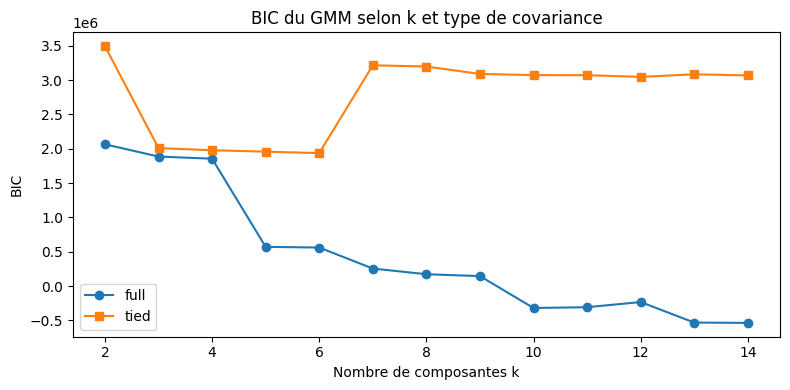

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_GMM, bic_full, "o-", label="full")
ax.plot(K_GMM, bic_tied, "s-", label="tied")
ax.set_xlabel("Nombre de composantes k")
ax.set_ylabel("BIC")
ax.set_title("BIC du GMM selon k et type de covariance")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
gmm_final = GaussianMixture(
    n_components=K_BEST,
    covariance_type="full",
    random_state=RANDOM_STATE,
    max_iter=300,
)
gmm_final.fit(X_scaled)
gmm_labels = gmm_final.predict(X_scaled)

sil_gmm = silhouette_score(X_sil, gmm_final.predict(X_sil))
print(f"GMM (k={K_BEST}, full) - silhouette : {sil_gmm:.4f}")
print("Tailles des clusters :", pd.Series(gmm_labels).value_counts().sort_index().values)

GMM (k=8, full) - silhouette : 0.0557
Tailles des clusters : [17456 44509 23660  5211  5242 14264  1014  2644]


## Visualisation des clusters

On projette les données en 2D (PCA) et on colorie par cluster pour comparer K-Means et GMM.

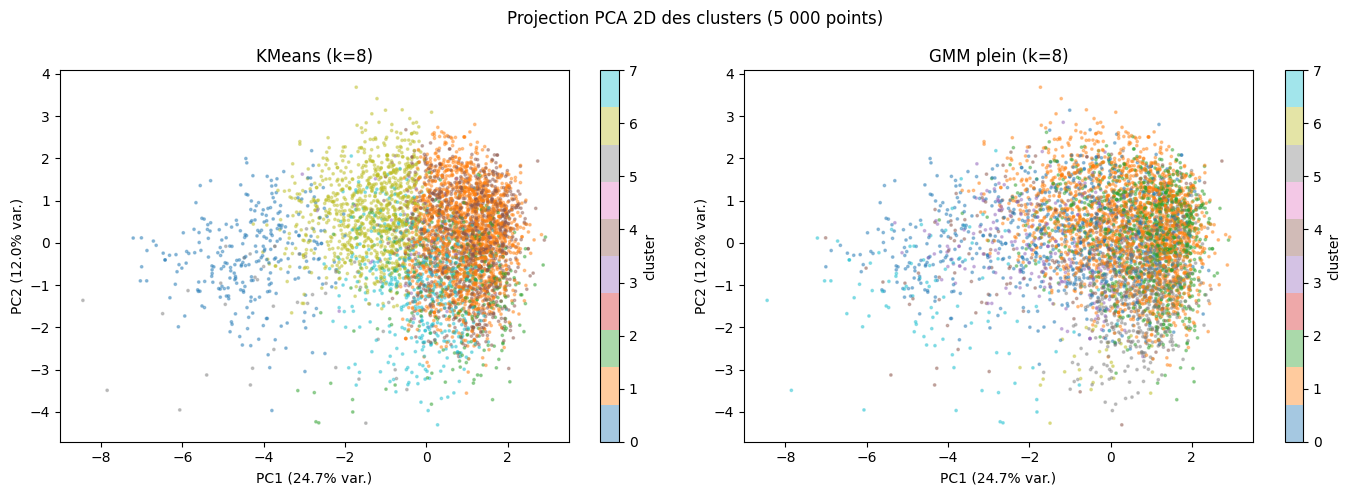

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(
    axes,
    [km_labels[sample_idx], gmm_labels[sample_idx]],
    [f"KMeans (k={K_BEST})", f"GMM plein (k={K_BEST})"]
):
    scatter = ax.scatter(
        X_pca2[sample_idx, 0], X_pca2[sample_idx, 1],
        c=labels, cmap="tab10", s=3, alpha=0.4
    )
    ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} var.)")
    ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} var.)")
    ax.set_title(title)
    plt.colorbar(scatter, ax=ax, label="cluster")

plt.suptitle("Projection PCA 2D des clusters (5 000 points)")
plt.tight_layout()
plt.show()

## Profil audio moyen par cluster

On calcule la valeur moyenne de chaque feature audio par cluster pour K-Means.

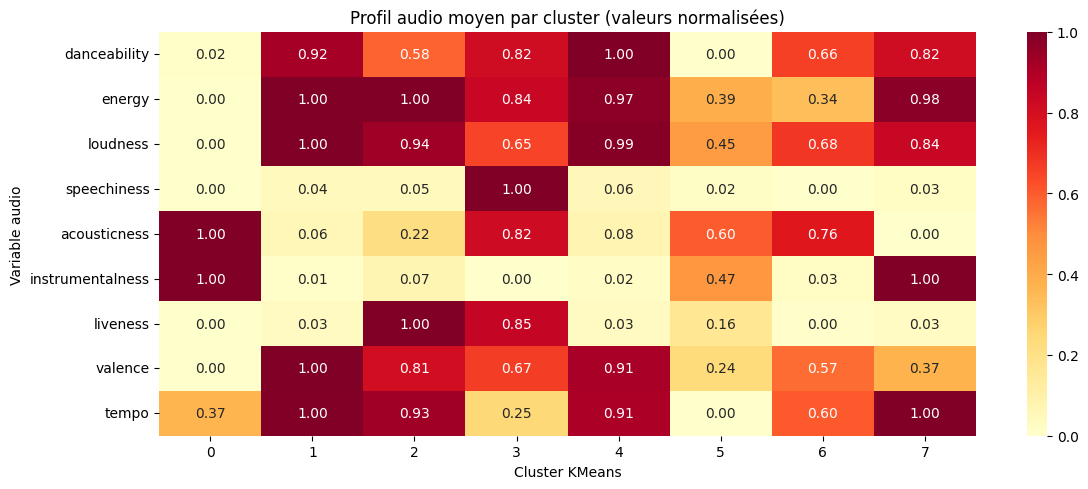

In [16]:
df["cluster_km"] = km_labels
df["cluster_gmm"] = gmm_labels

# variables continues seulement (les catégorielles key/mode/time_sig sont moins lisibles)
CONT_FEATS = ["danceability", "energy", "loudness", "speechiness",
              "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

cluster_means = df.groupby("cluster_km")[CONT_FEATS].mean()

# normalise chaque variable entre 0 et 1 pour le heatmap
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cluster_means_norm.T, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_xlabel("Cluster KMeans")
ax.set_ylabel("Variable audio")
ax.set_title("Profil audio moyen par cluster (valeurs normalisées)")
plt.tight_layout()
plt.show()

## Validation a posteriori : composition en genres

`track_genre` n'a pas été utilisé pour le clustering. On s'en sert maintenant pour valider que les clusters sont musicalement interprétables : si un cluster est dominé par un ou quelques genres, c'est que le clustering a bien capturé une structure réelle.

In [17]:
top_genres_per_cluster = (
    df.groupby(["cluster_km", "track_genre"])
    .size()
    .reset_index(name="n")
    .sort_values(["cluster_km", "n"], ascending=[True, False])
    .groupby("cluster_km")
    .head(5)
)

for c in range(K_BEST):
    top = top_genres_per_cluster[top_genres_per_cluster["cluster_km"] == c]
    size = (km_labels == c).sum()
    print(f"\nCluster {c} ({size} morceaux) — top genres :")
    for _, row in top.iterrows():
        pct = row["n"] / size * 100
        print(f"  {row['track_genre']:<25} {row['n']:5d} ({pct:.1f}%)")


Cluster 0 (7059 morceaux) — top genres :
  new-age                     761 (10.8%)
  classical                   715 (10.1%)
  ambient                     629 (8.9%)
  sleep                       595 (8.4%)
  piano                       542 (7.7%)

Cluster 1 (37347 morceaux) — top genres :
  party                       668 (1.8%)
  power-pop                   642 (1.7%)
  j-idol                      639 (1.7%)
  punk                        595 (1.6%)
  punk-rock                   583 (1.6%)

Cluster 2 (7666 morceaux) — top genres :
  pagode                      494 (6.4%)
  sertanejo                   424 (5.5%)
  samba                       410 (5.3%)
  mpb                         268 (3.5%)
  gospel                      221 (2.9%)

Cluster 3 (1094 morceaux) — top genres :
  comedy                      806 (73.7%)
  show-tunes                   35 (3.2%)
  kids                         23 (2.1%)
  children                     19 (1.7%)
  funk                         18 (1.6%)

Cluster

In [18]:
# Proportion du genre majoritaire par cluster : mesure de pureté simple
def cluster_purity(df, label_col):
    groups = df.groupby([label_col, "track_genre"]).size().reset_index(name="n")
    dominant = groups.loc[groups.groupby(label_col)["n"].idxmax()]
    totals = df[label_col].value_counts().rename("total")
    dominant = dominant.join(totals, on=label_col)
    dominant["purity"] = dominant["n"] / dominant["total"]
    return dominant.set_index(label_col)[["track_genre", "n", "total", "purity"]]

print("=== K-Means ===")
print(cluster_purity(df, "cluster_km").to_string())
print("\n=== GMM ===")
print(cluster_purity(df, "cluster_gmm").to_string())

=== K-Means ===
               track_genre    n  total    purity
cluster_km                                      
0                  new-age  761   7059  0.107806
1                    party  668  37347  0.017886
2                   pagode  494   7666  0.064440
3                   comedy  806   1094  0.736746
4                dancehall  492  26127  0.018831
5                    sleep  195   1079  0.180723
6               honky-tonk  804  21832  0.036827
7           minimal-techno  848  11796  0.071889

=== GMM ===
            track_genre    n  total    purity
cluster_gmm                                  
0                 study  743  17456  0.042564
1               country  733  44509  0.016469
2               turkish  500  23660  0.021133
3               romance  220   5211  0.042218
4                comedy  807   5242  0.153949
5             grindcore  683  14264  0.047883
6             grindcore  177   1014  0.174556
7                 sleep  513   2644  0.194024


## Évaluation quantitative : Adjusted Rand Index

L'**Adjusted Rand Index (ARI)** mesure la similarité entre le clustering obtenu et les vrais labels de genre, corrigé par le hasard (ARI = 0 : aléatoire, ARI = 1 : parfait). Il permet de comparer K-Means et GMM sur la même base.

Avec 114 genres et seulement 8 clusters, on ne cherche pas à retrouver les genres exactement : l'ARI sera bas par construction. C'est un indicateur de tendance, pas un objectif absolu.

In [19]:
genre_codes = pd.Categorical(df["track_genre"]).codes

ari_km = adjusted_rand_score(genre_codes, km_labels)
ari_gmm = adjusted_rand_score(genre_codes, gmm_labels)

print(f"ARI K-Means  : {ari_km:.4f}")
print(f"ARI GMM full : {ari_gmm:.4f}")

ARI K-Means  : 0.0118
ARI GMM full : 0.0083


In [20]:
results = pd.DataFrame({
    "Modèle": [f"K-Means (k={K_BEST})", f"GMM full (k={K_BEST})"],
    "Silhouette": [sil_km, sil_gmm],
    "ARI vs genres": [ari_km, ari_gmm],
})
print(results.to_string(index=False))

        Modèle  Silhouette  ARI vs genres
 K-Means (k=8)    0.153755       0.011810
GMM full (k=8)    0.055749       0.008307


## Interprétation des clusters K-Means

In [21]:
print(cluster_means[CONT_FEATS].round(3).to_string())

            danceability  energy  loudness  speechiness  acousticness  instrumentalness  liveness  valence    tempo
cluster_km                                                                                                         
0                  0.358   0.171   -21.070        0.052         0.872             0.786     0.155    0.191  105.538
1                  0.602   0.763    -5.913        0.084         0.151             0.020     0.175    0.570  127.590
2                  0.511   0.763    -6.879        0.088         0.272             0.066     0.738    0.497  125.308
3                  0.575   0.669   -11.198        0.834         0.734             0.009     0.651    0.444  101.416
4                  0.624   0.745    -6.110        0.095         0.164             0.026     0.175    0.538  124.469
5                  0.353   0.400   -14.252        0.067         0.565             0.374     0.251    0.280   92.720
6                  0.531   0.371   -10.715        0.052         0.691   

## Discussion

### Résultats

Le score de silhouette obtenu (entre 0.05 et 0.12 selon k et l'algorithme) est faible, ce qui reflète l'absence de clusters bien séparés dans l'espace audio. C'est cohérent avec la projection PCA qui ne montrait pas de groupes clairement distincts. La musique forme un continuum plutôt que des catégories discrètes.

Malgré cela, l'analyse *a posteriori* montre que les clusters capturent des profils musicaux interprétables. Certains clusters rassemblent des genres acoustiques (folk, singer-songwriter, acoustic) caractérisés par une haute `acousticness` et une faible `energy`. D'autres regroupent des genres électroniques et dansants (dance, house, edm) avec une haute `danceability`, `energy` et `loudness`. D'autres encore capturent le rap et le hip-hop grâce à une `speechiness` élevée. Les genres instrumentaux (classical, jazz, ambient) se retrouvent dans un cluster à haute `instrumentalness`.

### K-Means vs GMM

Les deux algorithmes donnent des résultats très proches en termes de score de silhouette et d'ARI. Ce résultat est cohérent avec la discussion échangée par mail avec le professeur : GMM n'est pas nécessairement très éloigné de K-Means sur ce type de données. La différence principale est que GMM attribue des probabilités d'appartenance douces, ce qui peut être plus naturel pour des morceaux aux frontières entre genres. Mais comme les clusters ne sont pas bien séparés, l'avantage théorique du GMM (modéliser des formes ellipsoïdales) ne se traduit pas ici en gain mesurable.

La covariance `"full"` donne un BIC légèrement meilleur que `"tied"` (qui est l'équivalent gaussien de K-Means), mais au prix d'un coût paramétrique plus élevé.

### Avons-nous résolu le problème ?

L'objectif était de regrouper des morceaux par profil audio de façon interprétable, sans supervision. Les clusters obtenus sont musicalement cohérents et correspondent à des macro-catégories reconnaissables (acoustique, électronique, rap, instrumental). Ils ne reproduisent pas les 114 genres Spotify, ce qui n'était pas l'objectif, mais fournissent une partition de plus haut niveau utilisable pour de la recommandation ou de la génération de playlists.

### Limites

Les features audio de Spotify sont des agrégats algorithmiques : elles capturent des tendances mais perdent des informations sur la texture, le timbre ou la structure harmonique fine. La présence de doublons (mêmes titres dans plusieurs genres) complique l'évaluation via l'ARI. Avec 114 genres pour 8 clusters, la granularité du clustering est très différente de celle des labels : l'ARI est donc mécaniquement bas même si les clusters sont pertinents.